# Behavioral Segmentation

🎯 Goal

Identify groups of customers based on how they behave as travelers — their flight frequency, travel style, loyalty behavior, and service usage patterns.
👉 This answers:

“How do our customers use the airline?”
“What habits or travel styles distinguish one group from another?”

🧩 Main Variables to Analyze

From FlightsDB mainly:

NumFlights

NumFlightsWithCompanions

DistanceKM

PointsAccumulated / PointsRedeemed

Month, Year → seasonal or temporal patterns

Possible engineered features:

Feature	Meaning
AvgFlightsPerMonth	Travel frequency
AvgDistancePerFlight	Long-haul vs short-haul traveler
PointsRedemptionRate	Loyalty engagement
CompanionRate	Solo vs group traveler
SeasonalityIndex	Travel pattern variation across months

In [9]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [10]:
flights= pd.read_csv('../data/cleaned/flights_cleaned.csv')
customers = pd.read_csv('../data/aggregated/customers_aggregations.csv')

In [11]:
print(customers.head)
print(flights.head)

<bound method NDFrame.head of        Loyalty# First Name    Last Name        Customer Name Country  \
0        480934    Cecilia  Householder  Cecilia Householder  Canada   
1        549612      Dayle        Menez          Dayle Menez  Canada   
2        429460     Necole       Hannon        Necole Hannon  Canada   
3        608370      Queen        Hagee          Queen Hagee  Canada   
4        530508     Claire      Latting       Claire Latting  Canada   
...         ...        ...          ...                  ...     ...   
16569    823768      Mandy     Sammarco       Mandy Sammarco  Canada   
16570    680886      Jamee         Ahlm           Jamee Ahlm  Canada   
16571    776187     Janina         Lumb          Janina Lumb  Canada   
16572    615459     Dannie       Paplow        Dannie Paplow  Canada   
16573    652627     Ariane       Peyton        Ariane Peyton  Canada   

      Province or State       City   Latitude   Longitude Postal code  ...  \
0               Ontario    

In [12]:
print("Customers columns:")
print(customers.columns)
print("\nFlights columns:")
print(flights.columns)

Customers columns:
Index(['Loyalty#', 'First Name', 'Last Name', 'Customer Name', 'Country',
       'Province or State', 'City', 'Latitude', 'Longitude', 'Postal code',
       'Gender', 'Education', 'Location Code', 'Income', 'Marital Status',
       'LoyaltyStatus', 'EnrollmentDateOpening', 'CancellationDate',
       'Customer Lifetime Value', 'EnrollmentType', 'IsActive', 'EndDate',
       'CustomerTenureDays', 'total_flights', 'total_flights_with_companions',
       'total_distance', 'total_points_accumulated', 'total_points_redeemed',
       'total_cost_redeemed', 'points_redemption_ratio',
       'companion_flight_ratio'],
      dtype='object')

Flights columns:
Index(['Loyalty#', 'Year', 'Month', 'YearMonthDate', 'NumFlights',
       'NumFlightsWithCompanions', 'DistanceKM', 'PointsAccumulated',
       'PointsRedeemed', 'DollarCostPointsRedeemed'],
      dtype='object')


In [13]:
#aggregation of flight behavior per customer's loyalty
flight_agg= flights_agg = flights.groupby('Loyalty#').agg({
    'NumFlights': 'sum',
    'NumFlightsWithCompanions': 'sum',
    'DistanceKM': 'sum',
    'PointsAccumulated': 'sum',
    'PointsRedeemed': 'sum'
}).reset_index()

flights_agg['PointsRedemptionRate'] = flights_agg['PointsRedeemed'] / flights_agg['PointsAccumulated']
flights_agg['CompanionRate'] = flights_agg['NumFlightsWithCompanions'] / flights_agg['NumFlights']
flights_agg['AvgDistancePerFlight'] = flights_agg['DistanceKM'] / flights_agg['NumFlights']


In [14]:
# check missing values on flight_agg
flights_agg.isin([np.nan, np.inf, -np.inf]).sum()


Loyalty#                       0
NumFlights                     0
NumFlightsWithCompanions       0
DistanceKM                     0
PointsAccumulated              0
PointsRedeemed                 0
PointsRedemptionRate        1469
CompanionRate               1469
AvgDistancePerFlight        1469
dtype: int64

In [15]:
flights_agg.head()

,Loyalty#,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,PointsRedemptionRate,CompanionRate,AvgDistancePerFlight
0,100018,225,45,530230.0,53014.30,20562.8,0.387873,0.200000,2356.577778
1,100102,245,55,339114.6,33903.96,18760.6,0.553345,0.224490,1384.141224
2,100140,218,51,432030.8,43192.58,4896.0,0.113353,0.233945,1981.792661
3,100214,144,17,364601.7,36453.77,12908.6,0.354109,0.118056,2531.956250
4,100272,202,50,429630.5,42953.25,10891.4,0.253564,0.247525,2126.883663


In [16]:
#Merging flight behavior with customer info
data = pd.merge(customers, flights_agg, on='Loyalty#', how='inner')
data.head()

,Loyalty#,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,Postal code,...,points_redemption_ratio,companion_flight_ratio,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,PointsRedemptionRate,CompanionRate,AvgDistancePerFlight
0,480934,Cecilia,Householder,Cecilia Householder,Canada,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,...,0.266628,0.245370,216,53,507054.9,50699.39,13517.9,0.266628,0.245370,2347.476389
1,549612,Dayle,Menez,Dayle Menez,Canada,Alberta,Edmonton,53.544388,-113.490930,T3G 6Y6,...,0.526282,0.104895,286,30,426827.4,42672.54,22457.8,0.526282,0.104895,1492.403497
2,429460,Necole,Hannon,Necole Hannon,Canada,British Columbia,Vancouver,49.282730,-123.120740,V6E 3D9,...,0.229922,0.258741,143,37,238376.1,23832.41,5479.6,0.229922,0.258741,1666.965734
3,608370,Queen,Hagee,Queen Hagee,Canada,Ontario,Toronto,43.653225,-79.383186,P1W 1K4,...,0.423144,0.277778,198,55,386029.3,38595.63,16331.5,0.423144,0.277778,1949.642929
4,530508,Claire,Latting,Claire Latting,Canada,Quebec,Hull,45.428730,-75.713364,J8Y 3Z5,...,0.000000,0.293532,201,59,369242.6,36916.56,0.0,0.000000,0.293532,1837.027861


In [17]:
#relevant features of segmentation
features = data[['NumFlights', 'NumFlightsWithCompanions', 'DistanceKM',
                 'PointsAccumulated', 'PointsRedeemed', 'PointsRedemptionRate',
                 'CompanionRate', 'AvgDistancePerFlight']]

features.describe()

,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,PointsRedemptionRate,CompanionRate,AvgDistancePerFlight
count,16574.000000,16574.000000,16574.000000,16574.000000,16574.000000,15105.000000,15105.000000,15105.000000
mean,144.805056,33.702063,287049.723989,28699.318453,8512.911621,0.315757,0.238760,2046.312773
std,81.723912,22.299848,163461.945565,16343.457707,8696.202956,0.501037,0.112764,637.649444
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,26.679167
25%,73.000000,15.000000,144610.425000,14458.267500,0.000000,0.065525,0.171053,1710.141758
50%,168.000000,35.000000,331463.550000,33138.865000,6499.950000,0.246882,0.230769,1983.992857
75%,207.000000,50.000000,413197.350000,41310.412500,13546.225000,0.442076,0.295082,2296.529412
max,343.000000,119.000000,712729.600000,71264.460000,57527.800000,33.267717,1.000000,12624.000000


In [18]:
#checking for missing values
features.isin([np.nan, np.inf, -np.inf]).sum()

NumFlights                     0
NumFlightsWithCompanions       0
DistanceKM                     0
PointsAccumulated              0
PointsRedeemed                 0
PointsRedemptionRate        1469
CompanionRate               1469
AvgDistancePerFlight        1469
dtype: int64

In [19]:
features = features.replace([np.inf, -np.inf], np.nan)
features = features.fillna(0)

In [20]:
#scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

In [21]:
#clustering(k-means)
kmeans = KMeans(n_clusters=4, random_state=42)
data['Cluster'] = kmeans.fit_predict(X_scaled)

data['Cluster'].value_counts()

Cluster
3    6874
2    4368
1    3488
0    1844
Name: count, dtype: int64

In [22]:
#analysing clusters
cluster_summary = data.groupby('Cluster')[['NumFlights', 'DistanceKM',
                                           'PointsRedemptionRate', 'CompanionRate',
                                           'AvgDistancePerFlight']].mean().round(2)

print(cluster_summary)

         NumFlights  DistanceKM  PointsRedemptionRate  CompanionRate  \
Cluster                                                                
0              6.42     7873.04                  0.02           0.05   
1             58.45   116944.67                  0.37           0.27   
2            203.96   404842.47                  0.52           0.28   
3            188.16   373405.49                  0.17           0.21   

         AvgDistancePerFlight  
Cluster                        
0                     1223.90  
1                     2220.71  
2                     2016.11  
3                     2021.87  


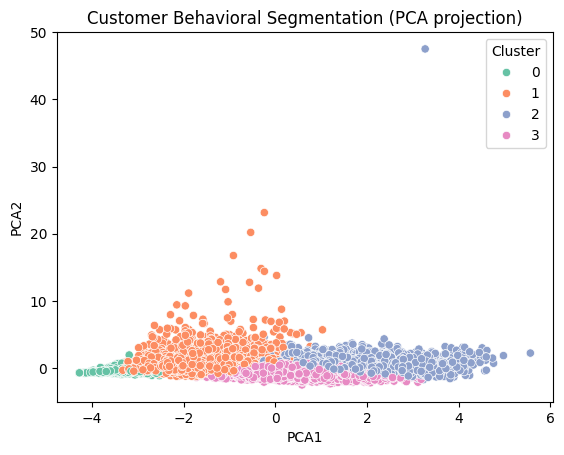

In [23]:
#visualization
from sklearn.decomposition import PCA
pca = PCA(2)
components = pca.fit_transform(X_scaled)
data['PCA1'], data['PCA2'] = components[:,0], components[:,1]

sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=data, palette='Set2')
plt.title('Customer Behavioral Segmentation (PCA projection)')
plt.show()


C:\Users\Esra\AppData\Local\Temp\ipykernel_24344\908806028.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y=col, data=data, palette='Set2')
C:\Users\Esra\AppData\Local\Temp\ipykernel_24344\908806028.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y=col, data=data, palette='Set2')
C:\Users\Esra\AppData\Local\Temp\ipykernel_24344\908806028.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y=col, data=data, palette='Set2')
C:\Users\Esra\AppData\Local\Temp\ipykernel_24344\908806028.py:6: FutureWa

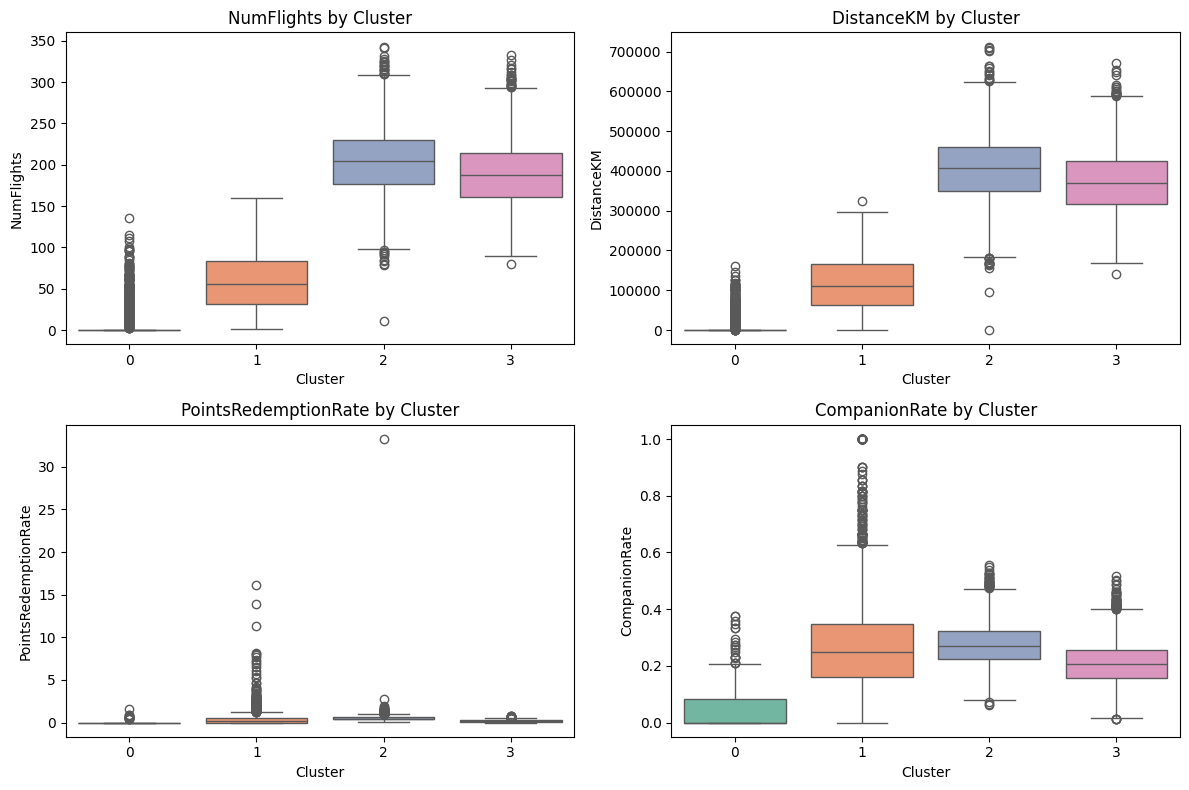

In [24]:
metrics = ['NumFlights', 'DistanceKM', 'PointsRedemptionRate', 'CompanionRate']
plt.figure(figsize=(12,8))

for i, col in enumerate(metrics, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x='Cluster', y=col, data=data, palette='Set2')
    plt.title(f'{col} by Cluster')

plt.tight_layout()
plt.show()

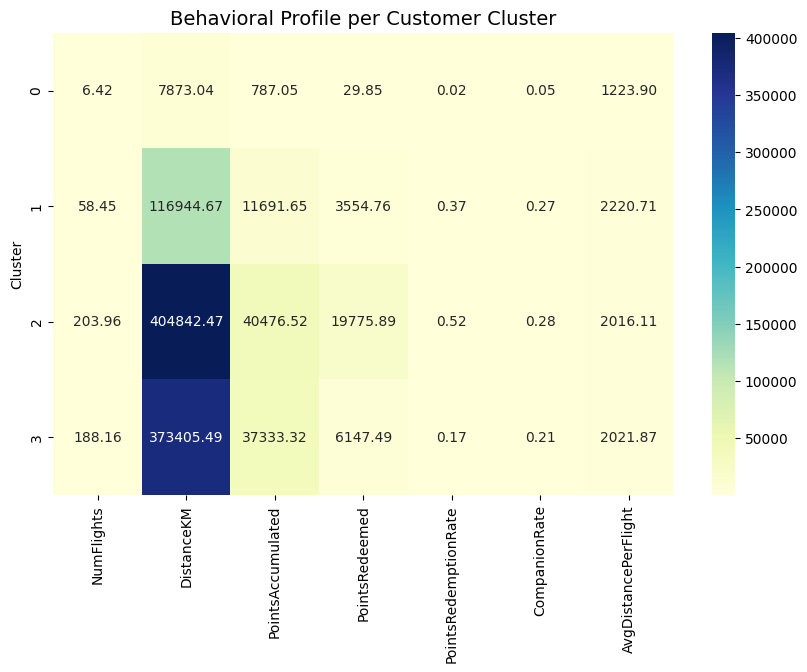

In [25]:
cluster_summary = data.groupby('Cluster')[[
    'NumFlights', 'DistanceKM', 'PointsAccumulated', 'PointsRedeemed',
    'PointsRedemptionRate', 'CompanionRate', 'AvgDistancePerFlight'
]].mean().round(2)

plt.figure(figsize=(10,6))
sns.heatmap(cluster_summary, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Behavioral Profile per Customer Cluster', fontsize=14)
plt.show()